# Demo 2D RL Environment for the PURT Course using Dynamic Programming

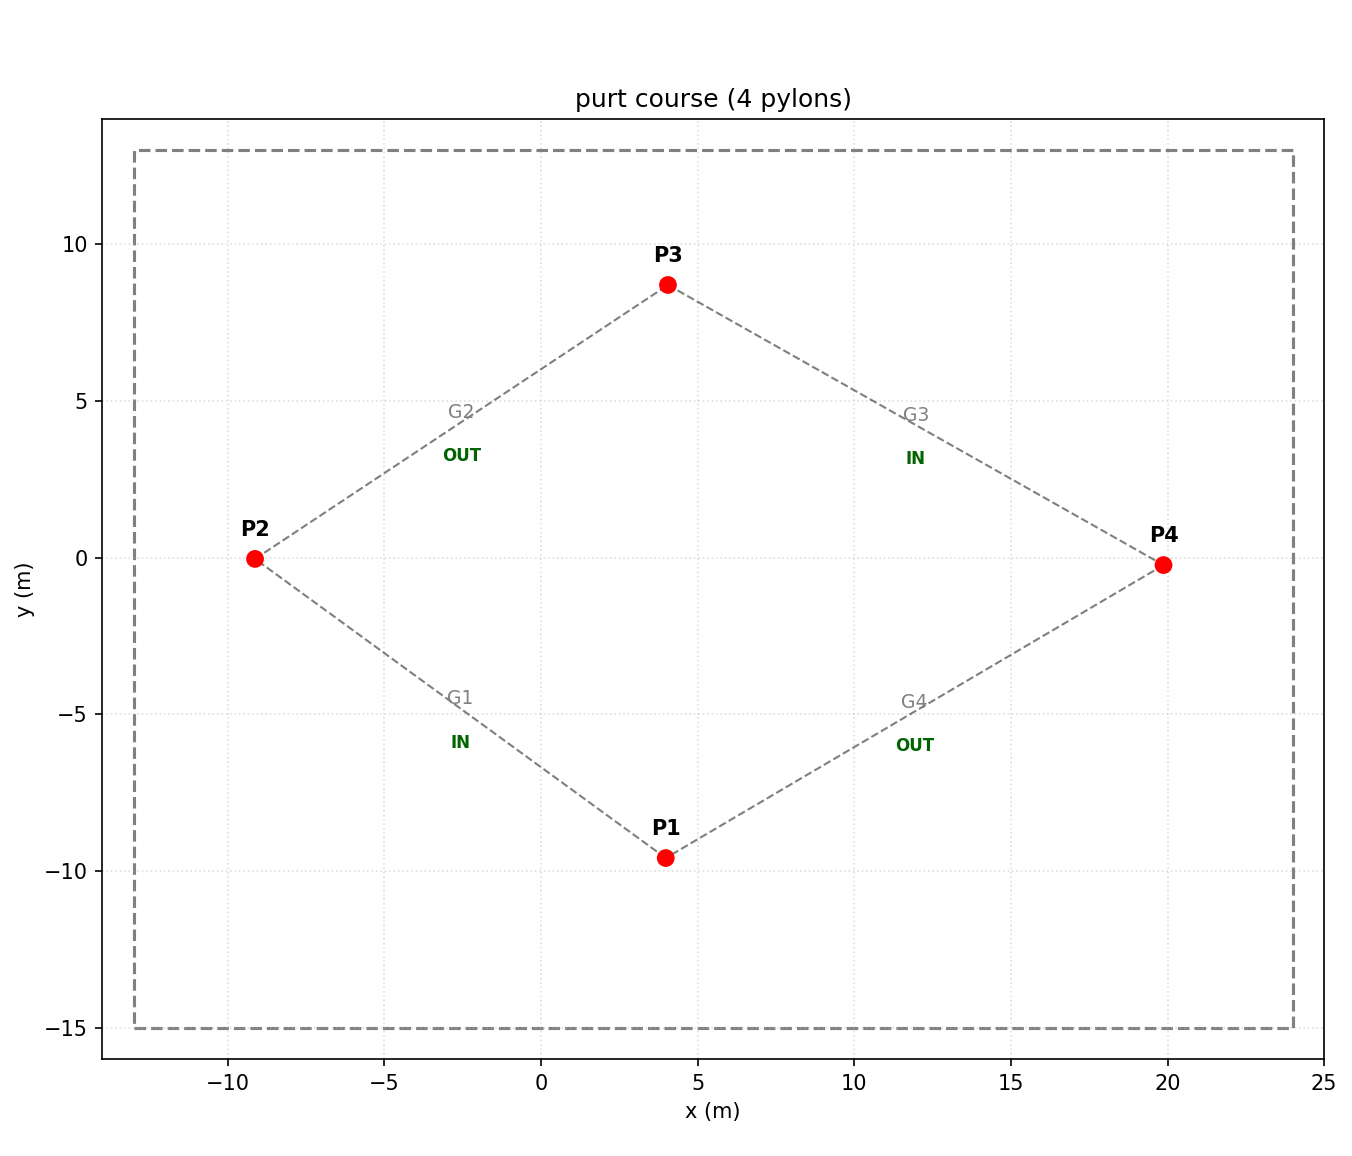

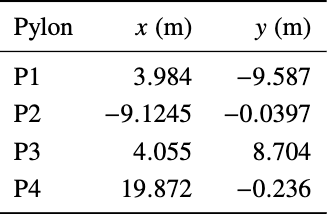

## Environment

### State Space
$\mathcal{S} \in \mathbb{Z} \cap \left[0,N_{\text{grid}}^2-1\right] \times \mathbb{Z} \cap \left[0,N_{\text{midpoint}}\right]$

$N_{\text{grid}}$: Number of grid cells in a single direction (we assume the grid is square)

$N_{\text{midpoint}}$: Number of midpoints between pylons

$\mathbb{Z} \cap \left[0,N_{\text{grid}}^2-1\right]$: 2D square grid of size $N_{\text{grid}} \times N_{\text{grid}}$ compressed into a scalar integer of maximum value $N_{\text{grid}}^2 - 1$ corresponding to the grid index number

$\mathbb{Z} \cap \left[0,N_{\text{midpoint}}\right]$: Number of midpoints visited

### Observation Space
$\mathcal{O} = \mathcal{S}$ (Same as the state space)

### Action Space
$\mathcal{A} \in \{0,1,2,3\}$

0: Up

1: Down

2: Left

3: Right

### Tranisition Logic
* Move deterministicaly in the direction of action as long as there is room to move and the current cell does not intersect a pylon.
* If there is no room to move in the direction of action or if the current cell intersects a pylon, remain stationary and end the episode.

### Rewards
* Reached next midpoint in order: $+1$
* Returned to starting point (endpoint) after going through all midpoints: $+1$
* Moved to a cell intersecting a pylon: $-1$

In [1]:
# Environment imports
import gymnasium as gym
from gymnasium import spaces
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.collections import LineCollection

In [2]:
# Define the action space as an enum
from enum import Enum

class Action(Enum):
    Right = 0
    Up = 1
    Left = 2
    Down = 3

In [3]:
# Simple PURT Environment
class SimplePURT(gym.Env):
    # PYLON_COORDINATES: Bottom left corner is (0,0), Top right corner is (1,1)
    def __init__(self, GRID_N=10, MAX_STEPS=100, REWARDS={"neutral": 0, "midpoint": 1, "endpoint": 1, "pylon": -1}, NOISE=0, INIT_STATE=np.asarray([0, 0]), PYLON_COORDINATES=np.array([[0.2, 0.2],[0.2,0.8],[0.8,0.8],[0.8,0.2]])):
        super(SimplePURT, self).__init__()
        
        self.GRID_N = GRID_N
        self.MAX_STEPS = MAX_STEPS
        self.REWARDS = REWARDS
        self.NOISE = NOISE # [0,1] -- 0: No Noise, 1: 100% Noise
        self.INIT_STATE = INIT_STATE.copy()

        self.PYLON_GRID_COORDINATES = np.round(PYLON_COORDINATES * (GRID_N - 1)).astype(int) # Convert pylon coordinates to grid coordinates
        self.PYLON_GRID_INDICES = self.PYLON_GRID_COORDINATES[:, 0] + self.PYLON_GRID_COORDINATES[:, 1] * GRID_N # Convert grid coordinates to grid indices
        
        self.PYLON_MIDPOINT_COORDINATES = np.zeros_like(PYLON_COORDINATES)
        for i in range(PYLON_COORDINATES.shape[0]):
            self.PYLON_MIDPOINT_COORDINATES[i] = 0.5 * (PYLON_COORDINATES[i] + PYLON_COORDINATES[(i + 1) % PYLON_COORDINATES.shape[0]]) # Midpoint between pylon i and pylon (i+1)
        self.PYLON_MIDPOINT_GRID_COORDINATES = np.round(self.PYLON_MIDPOINT_COORDINATES * (GRID_N - 1)).astype(int) # Convert midpoint coordinates to grid coordinates
        self.PYLON_MIDPOINT_INDICES = self.PYLON_MIDPOINT_GRID_COORDINATES[:, 0] + self.PYLON_MIDPOINT_GRID_COORDINATES[:, 1] * GRID_N # Convert grid coordinates to grid indices

        self.observation_space = spaces.MultiDiscrete([
            GRID_N * GRID_N, # Grid index number
            len(self.PYLON_MIDPOINT_INDICES) + 1 # Number of midpoints visited
        ])
        self.action_space = spaces.Discrete(4) # Action space
        self.state = INIT_STATE.copy() # Initial state
        self.n_steps = 0 # Keep track of the number of steps taken
        self.state_history = [INIT_STATE.copy()] # Keep track of the state history
        self.action_history = [] # Keep track of the action history
        
    def reset(self):
        self.state = self.INIT_STATE.copy()
        self.n_steps = 0
        self.state_history = [self.state.copy()]
        self.action_history = []
        return self.get_observation(), self.get_info()

    def step(self, action, ignore_truncation=False):
        new_state = self.state.copy()
        reward = self.REWARDS["neutral"]
        done = False
        truncated = False

        # 2D movement
        new_state[0] = self.get_new_position(action)

        # Reward
        if new_state[0] != self.state[0]:
            if new_state[0] in self.PYLON_GRID_INDICES:
                reward += self.REWARDS["pylon"] # Penalty for hitting a pylon
                done = True
            elif new_state[1] < len(self.PYLON_MIDPOINT_INDICES):
                if new_state[0] == self.PYLON_MIDPOINT_INDICES[new_state[1]]:
                    reward += self.REWARDS["midpoint"] # Reward for visiting midpoints in order
                    new_state[1] += 1 # Move to the next midpoint
            elif new_state[0] == self.INIT_STATE[0]:
                reward += self.REWARDS["endpoint"] # Reward for returning to initial state
                done = True
        else:
            done = True # If the agent tries to move out of bounds, end the episode

        self.state = new_state
        self.state_history.append(new_state.copy())
        self.action_history.append(action)

        if not ignore_truncation:
            self.n_steps += 1
            truncated = self.n_steps >= self.MAX_STEPS # Truncate the episode after MAX_STEPS

        return self.get_observation(), reward, done, truncated, self.get_info()
    
    def get_observation(self):
        return self.state
    
    def get_info(self):
        return {"state_history": self.state_history, "action_history": self.action_history}
    
    def get_possible_next_states(self, action):
        # 1. Determine probabilities for noise tendencies
        # Noise = 0 -> prob_intended = 1.0, prob_dev = 0.0
        p_dev = self.NOISE / 3.0
        p_intended = 1.0 - (2.0 * p_dev)

        # Map tendencies (-1: left shift, 0: intended, 1: right shift) to probabilities
        tendencies = [
            (0, p_intended),
            (-1, p_dev),
            (1, p_dev)
        ]

        possible_transitions = {} # Key: (next_position, next_midpoint_count), Value: [prob, reward]

        for tendency, prob in tendencies:
            if prob <= 0:
                continue  # Skip zero-probability transitions

            # Determine effective action based on tendency logic from get_new_position
            transition = Action(action)
            if tendency != 0:
                match transition:
                    case Action.Up:
                        transition = Action.Right if tendency == 1 else Action.Left
                    case Action.Down:
                        transition = Action.Left if tendency == 1 else Action.Right
                    case Action.Left:
                        transition = Action.Up if tendency == 1 else Action.Down
                    case Action.Right:
                        transition = Action.Down if tendency == 1 else Action.Up

            # Compute next grid position index
            curr_pos = self.state[0]
            match transition:
                case Action.Up:
                    new_pos = (curr_pos + self.GRID_N) if curr_pos < self.GRID_N * (self.GRID_N - 1) else curr_pos
                case Action.Down:
                    new_pos = (curr_pos - self.GRID_N) if curr_pos >= self.GRID_N else curr_pos
                case Action.Left:
                    new_pos = (curr_pos - 1) if curr_pos % self.GRID_N != 0 else curr_pos
                case Action.Right:
                    new_pos = (curr_pos + 1) if (curr_pos + 1) % self.GRID_N != 0 else curr_pos

            # Calculate reward and next state logic matching step()
            new_state = self.state.copy()
            reward = self.REWARDS["neutral"]
            done = False

            if new_pos != curr_pos:
                new_state[0] = new_pos
                if new_pos in self.PYLON_GRID_INDICES:
                    reward += self.REWARDS["pylon"]
                    done = True
                elif new_state[1] < len(self.PYLON_MIDPOINT_INDICES):
                    if new_pos == self.PYLON_MIDPOINT_INDICES[new_state[1]]:
                        reward += self.REWARDS["midpoint"]
                        new_state[1] += 1
                elif new_pos == self.INIT_STATE[0]:
                    reward += self.REWARDS["endpoint"]
            else:
                # Out-of-bounds boundary bump
                done = True
                pass

            state_key = (int(new_state[0]), int(new_state[1]))

            # Aggregate probabilities if different noise tendencies lead to identical outcome states
            if state_key in possible_transitions:
                possible_transitions[state_key][0] += prob
            else:
                possible_transitions[state_key] = [prob, reward, done]

        # Convert results into required format [[next_state_array, prob, reward], ...]
        results = []
        for (pos, midpoints_visited), (p, r, d) in possible_transitions.items():
            next_state_arr = np.array([pos, midpoints_visited], dtype=int)
            results.append([next_state_arr, p, r, d])

        return results
    
    def get_new_position(self, action):
        # 1. Simplify noise sampling (equivalent to your normal ppf logic)
        p_dev = self.NOISE / 3.0
        tendency = np.random.choice([-1, 0, 1], p=[p_dev, 1 - 2 * p_dev, p_dev])

        # 2. Resolve direction shift if noise occurs
        transition = Action(action)
        if tendency != 0:
            match transition:
                case Action.Up:
                    transition = Action.Right if tendency == 1 else Action.Left
                case Action.Down:
                    transition = Action.Left if tendency == 1 else Action.Right
                case Action.Left:
                    transition = Action.Up if tendency == 1 else Action.Down
                case Action.Right:
                    transition = Action.Down if tendency == 1 else Action.Up

        # 3. Calculate grid position with boundary limits
        curr_pos = self.state[0]
        match transition:
            case Action.Up:
                return (curr_pos + self.GRID_N) if curr_pos < self.GRID_N * (self.GRID_N - 1) else curr_pos
            case Action.Down:
                return (curr_pos - self.GRID_N) if curr_pos >= self.GRID_N else curr_pos
            case Action.Left:
                return (curr_pos - 1) if curr_pos % self.GRID_N != 0 else curr_pos
            case Action.Right:
                return (curr_pos + 1) if (curr_pos + 1) % self.GRID_N != 0 else curr_pos
    
    def render(self, ax=None, title=None, legend_outside=True):
        # 1. Initialize the plot (or draw into a caller-provided axes for side-by-side comparisons)
        standalone = ax is None
        if standalone:
            fig, ax = plt.subplots(figsize=(7, 7))
        ax.set_xlim(-0.5, self.GRID_N - 0.5)
        ax.set_ylim(-0.5, self.GRID_N - 0.5)
        
        # Configure grid lines to match your matrix index boundary points
        ax.set_xticks(np.arange(self.GRID_N))
        ax.set_yticks(np.arange(self.GRID_N))
        ax.grid(True, which='both', color='gainsboro', linestyle='-', linewidth=0.5)
        
        # 2. Extract and Plot Pylons (|)
        px = self.PYLON_GRID_COORDINATES[:, 0]
        py = self.PYLON_GRID_COORDINATES[:, 1]
        ax.scatter(px, py, color='firebrick', marker='|', s=250, linewidths=3, label='Pylon')
            
        # 3. Extract and Plot Midpoints (o)
        mx = self.PYLON_MIDPOINT_GRID_COORDINATES[:, 0]
        my = self.PYLON_MIDPOINT_GRID_COORDINATES[:, 1]
        ax.scatter(mx, my, color='darkorange', marker='o', s=100, facecolors='none', edgecolors='darkorange', linewidths=2, label='Midpoint')

        # 4. Process and Plot Agent Path Line (With Smooth Continuous Gradient)
        if self.state_history:
            path_x = np.array([state[0] % self.GRID_N for state in self.state_history])
            path_y = np.array([state[0] // self.GRID_N for state in self.state_history])
            
            # --- Continuous Gradient Line Implementation via Interpolation ---
            if len(path_x) > 1:
                # Interpolate 100 fine points between every step to blend colors flawlessly
                num_interp_points = (len(path_x) - 1) * 100
                t_original = np.arange(len(path_x))
                t_fine = np.linspace(0, len(path_x) - 1, num_interp_points)
                
                fine_x = np.interp(t_fine, t_original, path_x)
                fine_y = np.interp(t_fine, t_original, path_y)
                
                # Reshape the upscaled points into micro-segments
                points = np.array([fine_x, fine_y]).T.reshape(-1, 1, 2)
                segments = np.concatenate([points[:-1], points[1:]], axis=1)
                
                # --- CONTROLLING THE COLOR SHIFT RATE ---
                # Default was np.linspace(0, 1, len(segments))
                # Adjust 'max_shift' to control how far along the colormap the path gets.
                # 0.4 means it will only shift through 40% of the colormap over the entire path.
                max_shift = 1
                path_progression = np.linspace(0, max_shift, len(segments))
                # ----------------------------------------
                
                lc = LineCollection(segments, cmap='plasma', linewidths=3, alpha=0.9, zorder=2)
                lc.set_array(path_progression)
                
                # CRITICAL: Fix the colormap scaling limits so 1.0 remains the absolute ceiling
                lc.set_clim(0, 1) 
                
                ax.add_collection(lc)
                
                # Add a dummy handle so 'Agent Path' still shows up nicely in the legend
                from matplotlib.lines import Line2D
                legend_dummy = Line2D([0], [0], color=plt.get_cmap('plasma')(0.5), lw=3, label='Agent Path')
                # We will handle adding this dummy to the legend safely below
            # -----------------------------------------------------------------
            
            # Overlay directional action markers at each step along the line
            action_markers = {Action.Up.value: '^', Action.Down.value: 'v', Action.Left.value: '<', Action.Right.value: '>'}
            for i, action in enumerate(self.action_history):
                if action in action_markers:
                    ax.scatter(path_x[i], path_y[i], color='dodgerblue', marker=action_markers[action], s=80, zorder=3)
            
            # Distinctly mark Start and Finish states
            ax.scatter(path_x[0], path_y[0], color='forestgreen', marker='s', s=120, label='Start', zorder=4)
            ax.scatter(path_x[-1], path_y[-1], color='gold', marker='*', s=250, edgecolor='black', label='Finish', zorder=4)

        # 5. Labels and Legends
        ax.set_title(title or "SimplePURT Grid Visualization", fontsize=14, fontweight='bold', pad=15)
        ax.set_aspect('equal')
        
        # Adjust legend rendering to cleanly include our gradient dummy line
        handles, labels = ax.get_legend_handles_labels()
        if self.state_history and len(path_x) > 1:
            handles.append(legend_dummy)
            labels.append('Agent Path')
        if legend_outside:
            ax.legend(handles, labels, loc='upper left', bbox_to_anchor=(1.02, 1), borderaxespad=0)
        else:
            # Compact in-axes legend so multiple subplots can sit side by side without overlapping
            ax.legend(handles, labels, loc='upper right', fontsize=8, framealpha=0.9)
        
        if standalone:
            plt.tight_layout()
            plt.show()

## Policy Iteration

In [4]:
# Policy evaluation function
def policy_evaluation(env, policy, V, discount_factor, theta):
    while True:
        delta = 0
        for s in np.ndindex(*env.observation_space.nvec):
            s = np.asarray(s)
            old_v, V[*s] = V[*s], 0
            env.state = s # Set the environment state to the current state
            for next_state, prob, reward, done in env.get_possible_next_states(policy[s[0], s[1]]):
                V[*s] += reward + discount_factor * prob * V[*next_state] * (1 - done) # Bellman Expectation equation
            delta = max(delta, np.abs(old_v - V[*s]))
        if delta < theta: # Convergence condition
            break
    return V

In [5]:
# Policy improvement function
def policy_improvement(env, policy, V, discount_factor):
    policy_stable = True
    for s in np.ndindex(*env.observation_space.nvec):
        s = np.asarray(s)
        old_action = policy[*s]
        Q = np.zeros(env.action_space.n, dtype=np.float64)
        for a in range(env.action_space.n):
            env.state = s # Set the environment state to the current state
            for next_state, prob, reward, done in env.get_possible_next_states(a):
                Q[a] += reward + discount_factor * prob * V[*next_state] * (1 - done) # Q-values based on the current state-values
        policy[*s] = np.argmax(Q) # Greedy policy
        if old_action != policy[*s]: # Stability condition
            policy_stable = False
    return policy, policy_stable

In [6]:
# Policy iteration function
def policy_iteration(env, discount_factor, theta):
    policy = np.random.randint(env.action_space.n, size=env.observation_space.nvec, dtype=np.int8) # Initialize a policy
    V = np.zeros(env.observation_space.nvec, dtype=np.float64) # Initialize state-value function
    n_iter = 0
    while True:
        n_iter += 1
        # 1. Find V* for the current policy
        V = policy_evaluation(env, policy, V, discount_factor, theta)
        # 2. Find policy* for the current values
        policy, policy_stable = policy_improvement(env, policy, V, discount_factor)
        if policy_stable:
            break
    return policy, V, n_iter

## Value Iteration

**Things to add**
* Simple explanation of what VI is
* How it differs from policy iteration
* Graphic of convergence from Sutton
* Comparisons with different tests (varying grid sizes and rewards) measured by speed (passes and step calls)

$$V_{k+1}(s) = \max_a \sum_{s', r} p(s', r \vert{} s, a) \left[ r + \gamma V_k(s') \right]$$

$$\pi^*(s) = \arg\max_a \sum_{s', r} p(s', r \vert{} s, a) \left[ r + \gamma V^*(s') \right]$$

In [7]:
# Value iteration function
def value_iteration(env, discount_factor, theta):
    V = np.zeros(env.observation_space.nvec, dtype=np.float64) # Initialize state-value function
    n_iter = 0
    
    # 1. Find V* by sweeping the Bellman Optimality equation until it converges
    while True:
        n_iter += 1
        delta = 0
        for s in np.ndindex(*env.observation_space.nvec):
            s = np.asarray(s)
            old_v = V[*s]
            Q = np.zeros(env.action_space.n, dtype=np.float64)
            for a in range(env.action_space.n):
                env.state = s # Set the environment state to the current state
                for next_state, prob, reward, done in env.get_possible_next_states(a):
                    Q[a] += reward + discount_factor * prob * V[*next_state] * (1 - done)
            V[*s] = np.max(Q) # max instead of following a fixed policy
            delta = max(delta, np.abs(old_v - V[*s]))
        if delta < theta:
            break
    
    # 2. Extract the greedy policy from V* (with one final pass, no loop)
    policy = np.random.randint(env.action_space.n, size=env.observation_space.nvec, dtype=np.int8)
    for s in np.ndindex(*env.observation_space.nvec):
        s = np.asarray(s)
        Q = np.zeros(env.action_space.n, dtype=np.float64)
        for a in range(env.action_space.n):
            env.state = s
            for next_state, prob, reward, done in env.get_possible_next_states(a):
                Q[a] += reward + discount_factor * prob * V[*next_state] * (1 - done)
        policy[*s] = np.argmax(Q)

    return policy, V, n_iter
    

## Verification and Visualization

In [8]:
# Policy test function
def test_policy(env, policy, ax=None, title=None, legend_outside=True):
    env.reset()
    while True:
        observation, reward, done, truncated, info = env.step(policy[env.state[0], env.state[1]])
        if done or truncated:
            break
    env.render(ax=ax, title=title, legend_outside=legend_outside)

Policy Iteration completed in 18 iterations.


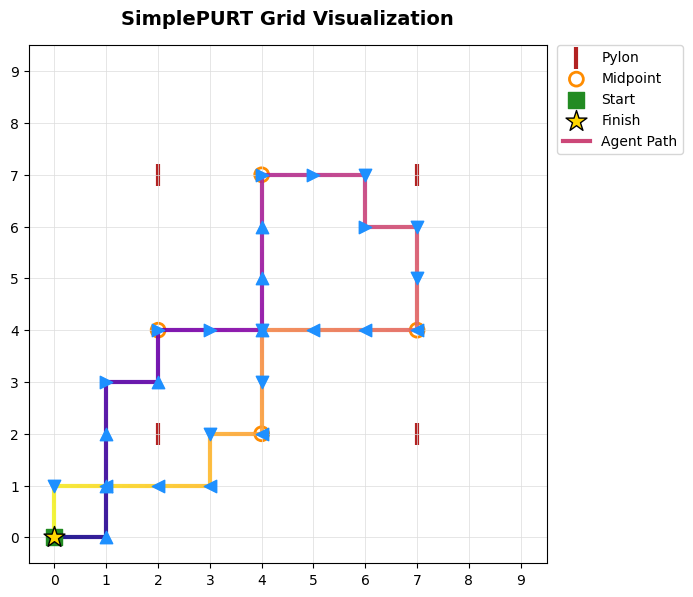

In [9]:
# Policy iteration visualization
PI_env = SimplePURT(GRID_N=10)
PI_policy, PI_V, PI_n_iter = policy_iteration(PI_env, discount_factor=0.9, theta=0.1)
print(f"Policy Iteration completed in {PI_n_iter} iterations.")
test_policy(PI_env, PI_policy)

Value Iteration completed in 16 sweeps.


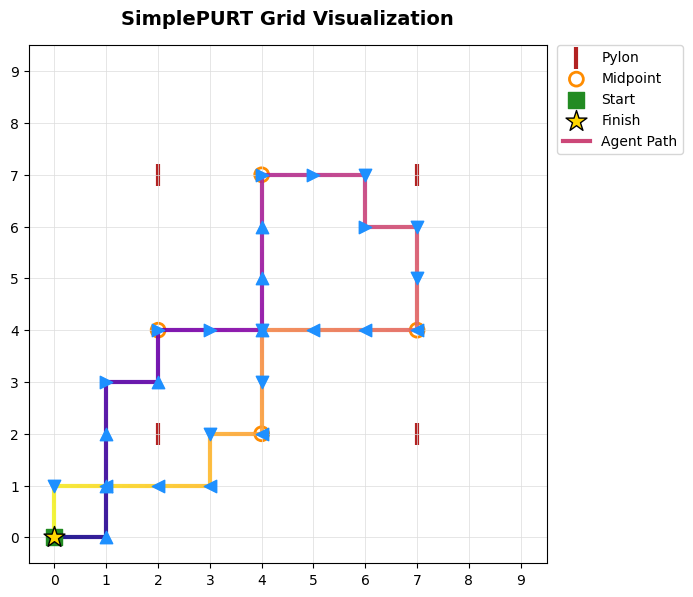

In [10]:
# Value iteration visualization
VI_env = SimplePURT(GRID_N=10)
VI_policy, VI_V, VI_n_iter = value_iteration(VI_env, discount_factor=0.9, theta=0.1)
print(f"Value Iteration completed in {VI_n_iter} sweeps.")
test_policy(VI_env, VI_policy)

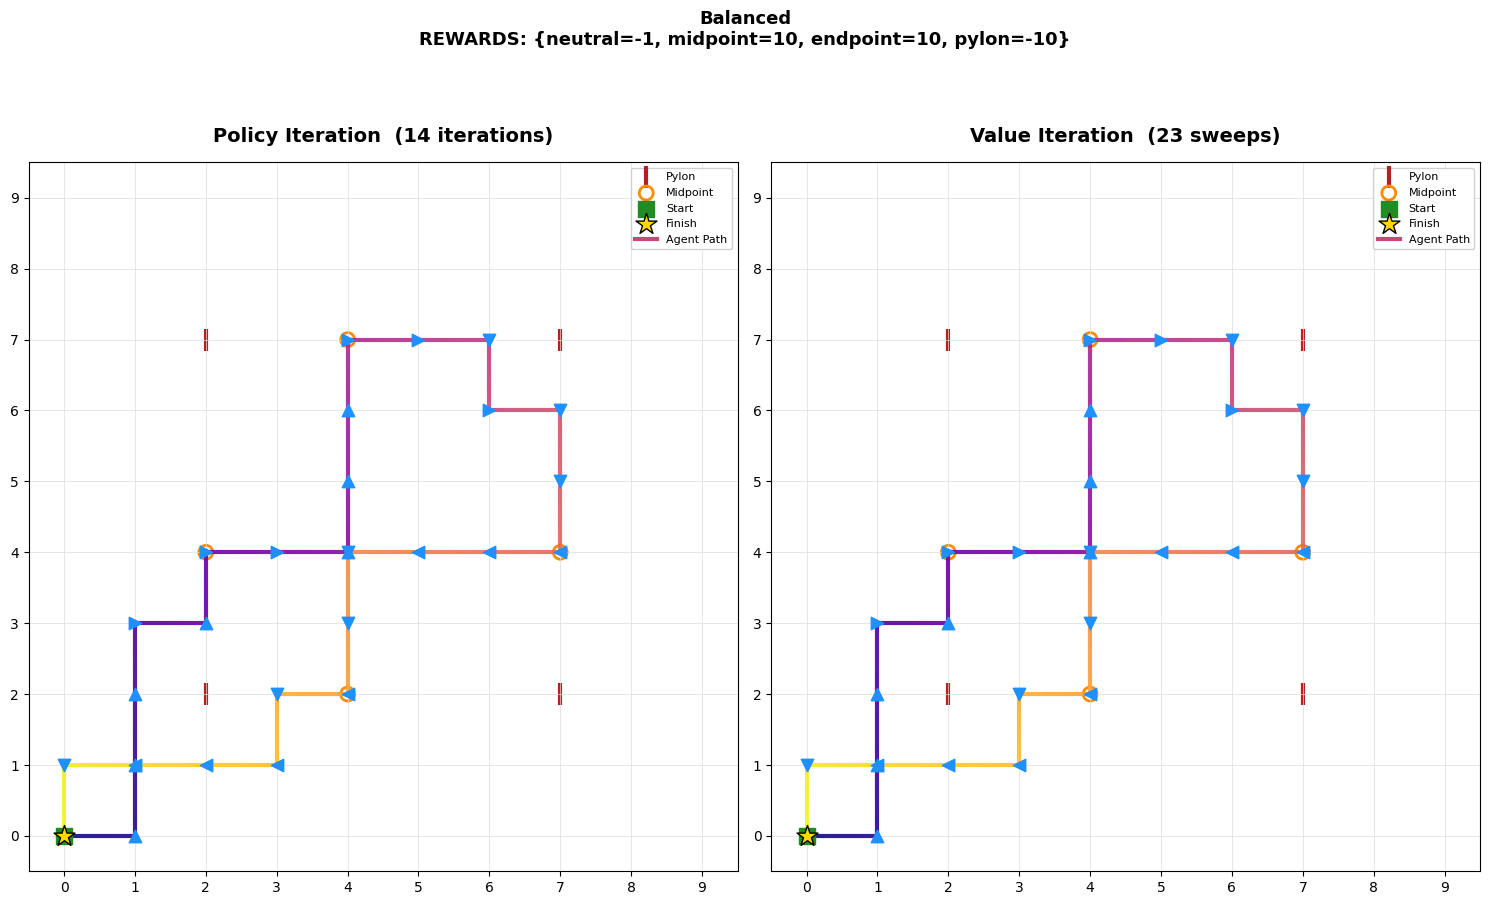

REWARD CONFIG : Balanced
REWARDS       : {'neutral': -1, 'midpoint': 10, 'endpoint': 10, 'pylon': -10}
                              Policy Iteration     Value Iteration
  Outer loop count                          14                  23
  Time (ms)                            1214.05              540.51



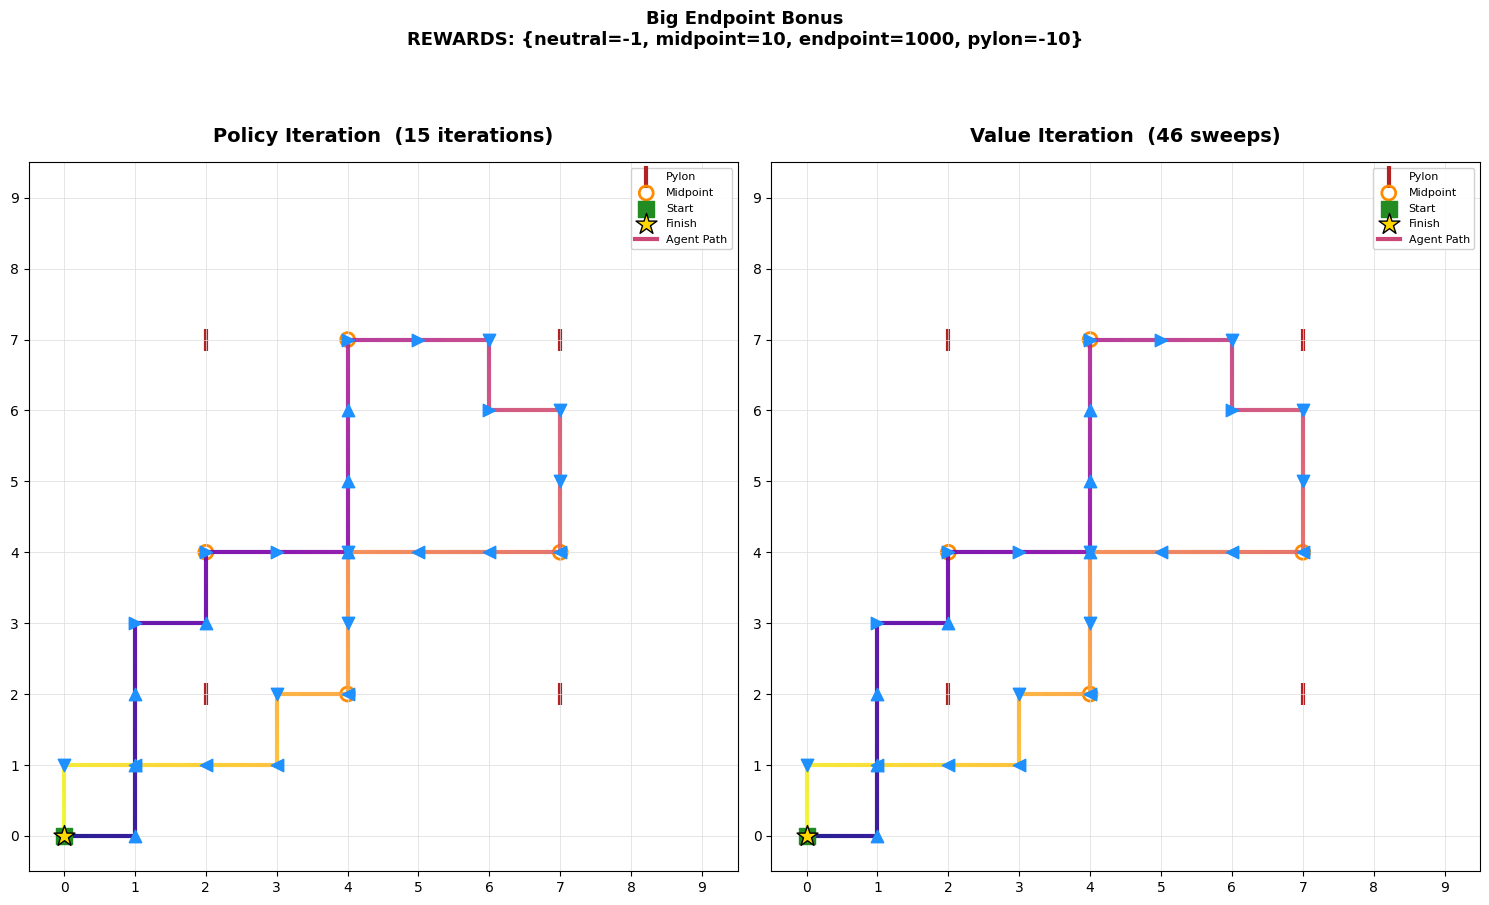

REWARD CONFIG : Big Endpoint Bonus
REWARDS       : {'neutral': -1, 'midpoint': 10, 'endpoint': 1000, 'pylon': -10}
                              Policy Iteration     Value Iteration
  Outer loop count                          15                  46
  Time (ms)                            2548.10             1705.71



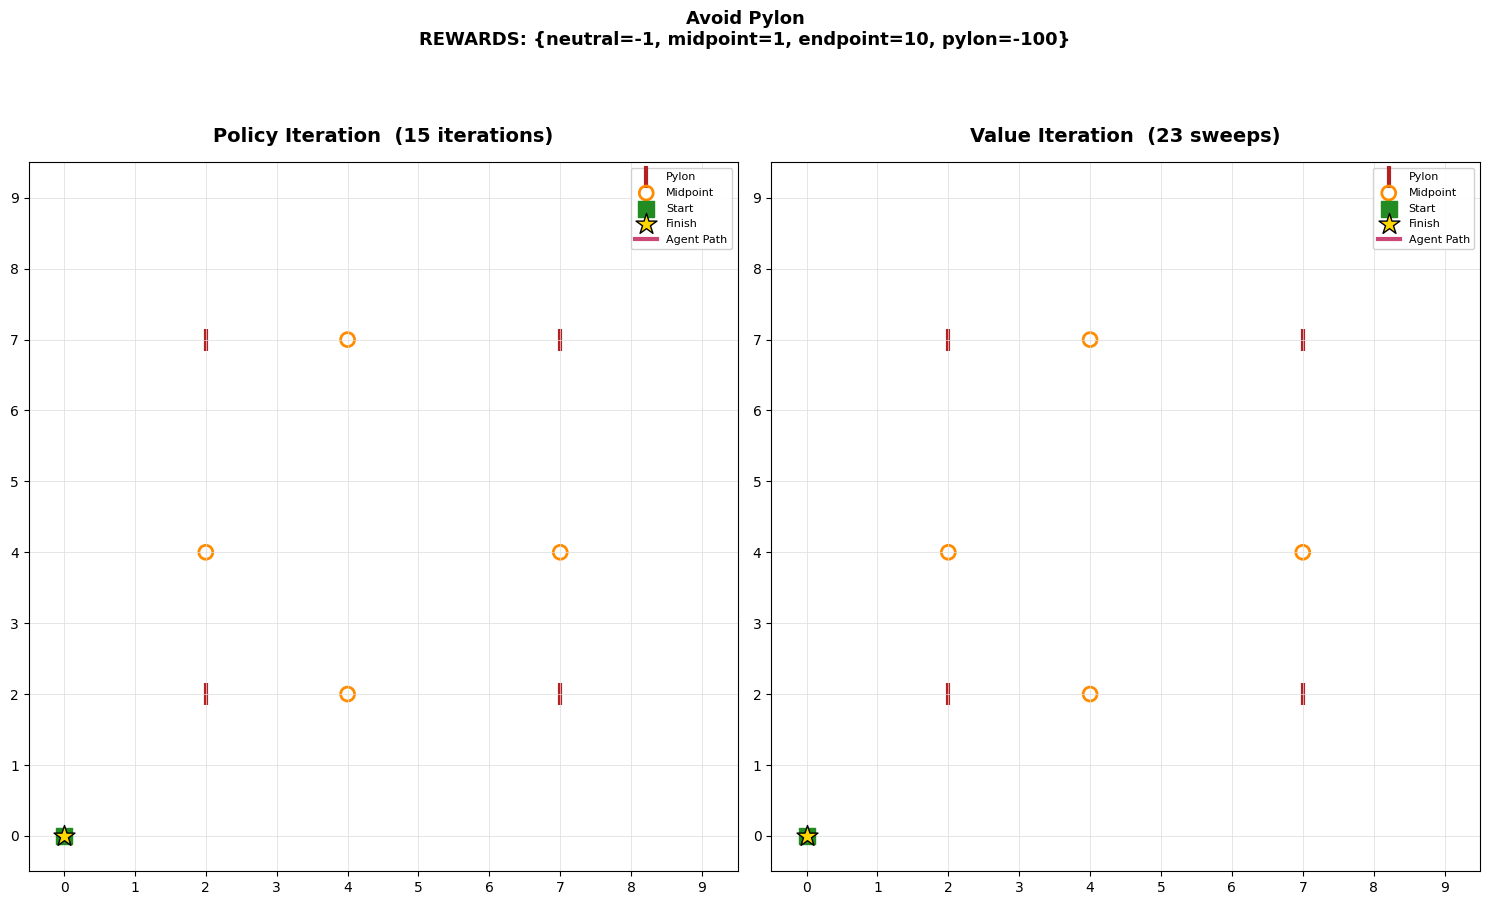

REWARD CONFIG : Avoid Pylon
REWARDS       : {'neutral': -1, 'midpoint': 1, 'endpoint': 10, 'pylon': -100}
                              Policy Iteration     Value Iteration
  Outer loop count                          15                  23
  Time (ms)                            1258.82             1352.19



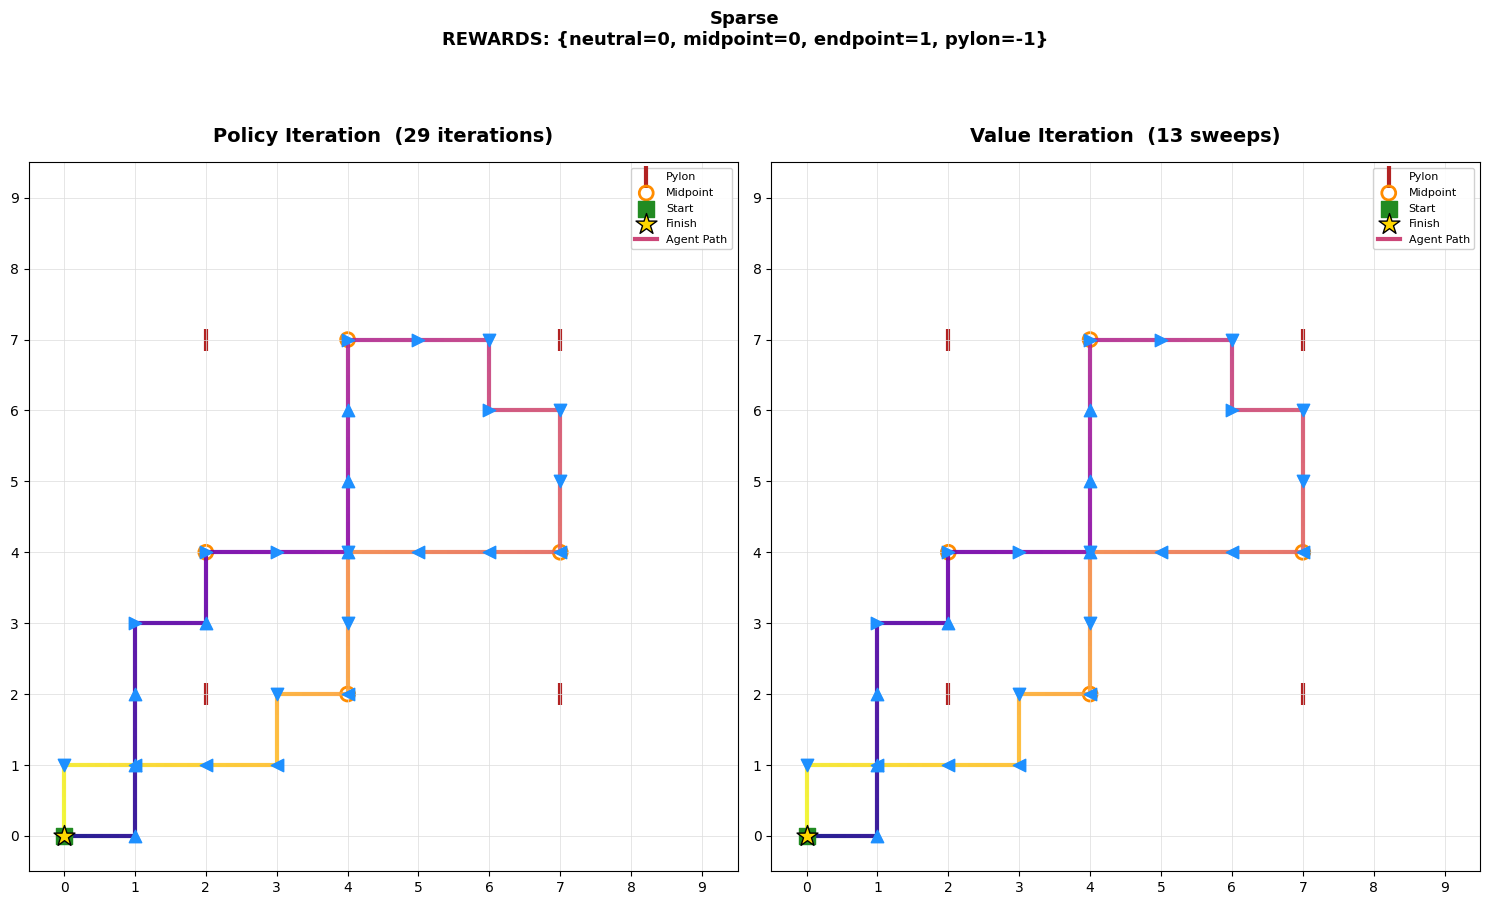

REWARD CONFIG : Sparse
REWARDS       : {'neutral': 0, 'midpoint': 0, 'endpoint': 1, 'pylon': -1}
                              Policy Iteration     Value Iteration
  Outer loop count                          29                  13
  Time (ms)                            1436.39              257.36



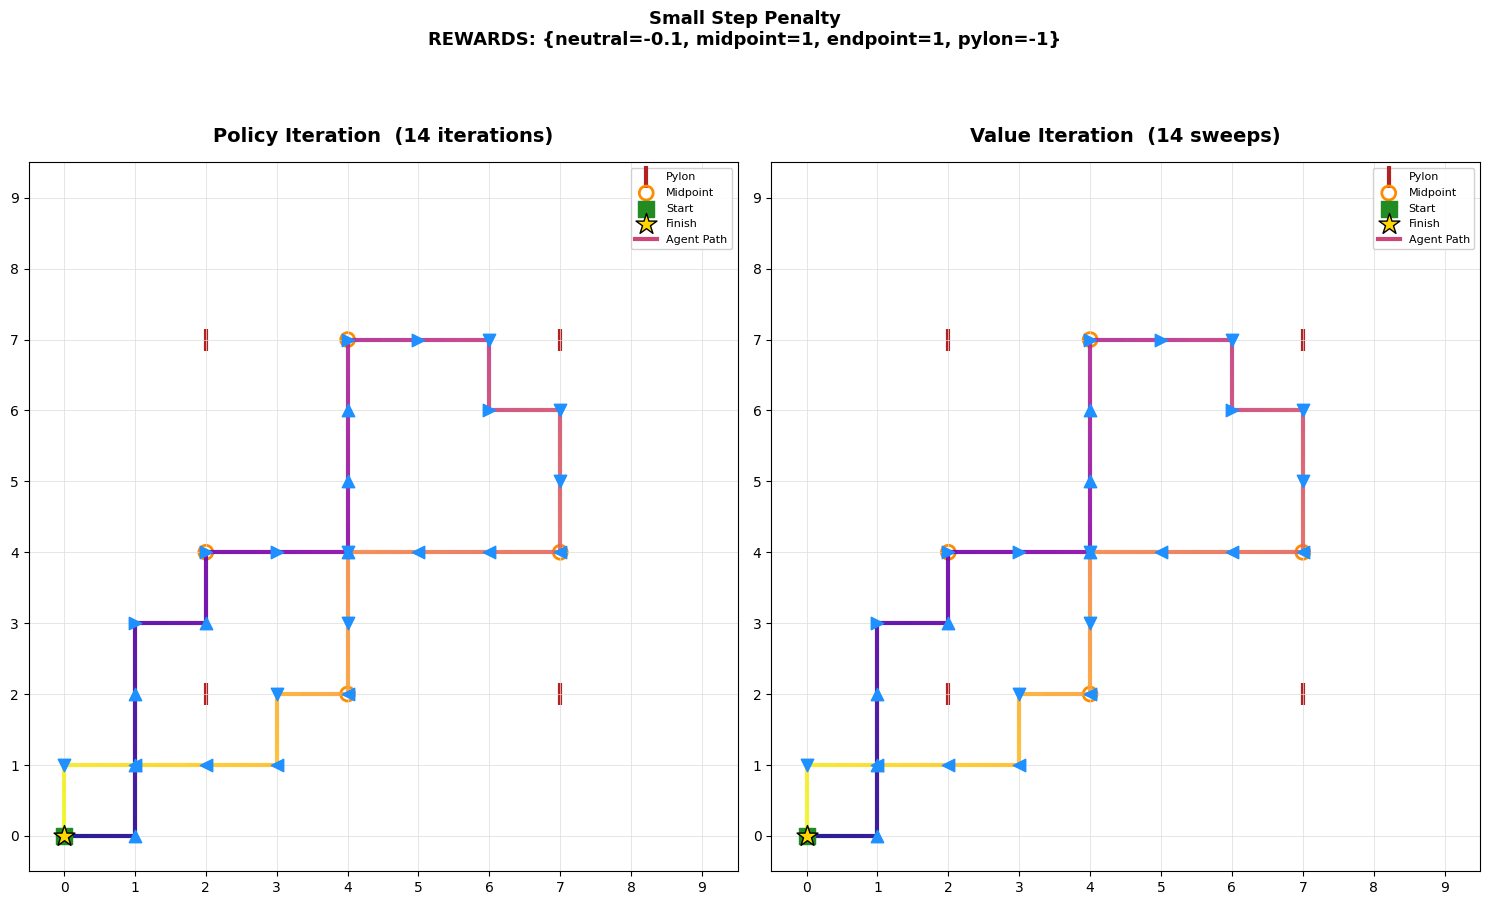

REWARD CONFIG : Small Step Penalty
REWARDS       : {'neutral': -0.1, 'midpoint': 1, 'endpoint': 1, 'pylon': -1}
                              Policy Iteration     Value Iteration
  Outer loop count                          14                  14
  Time (ms)                             720.87              291.22



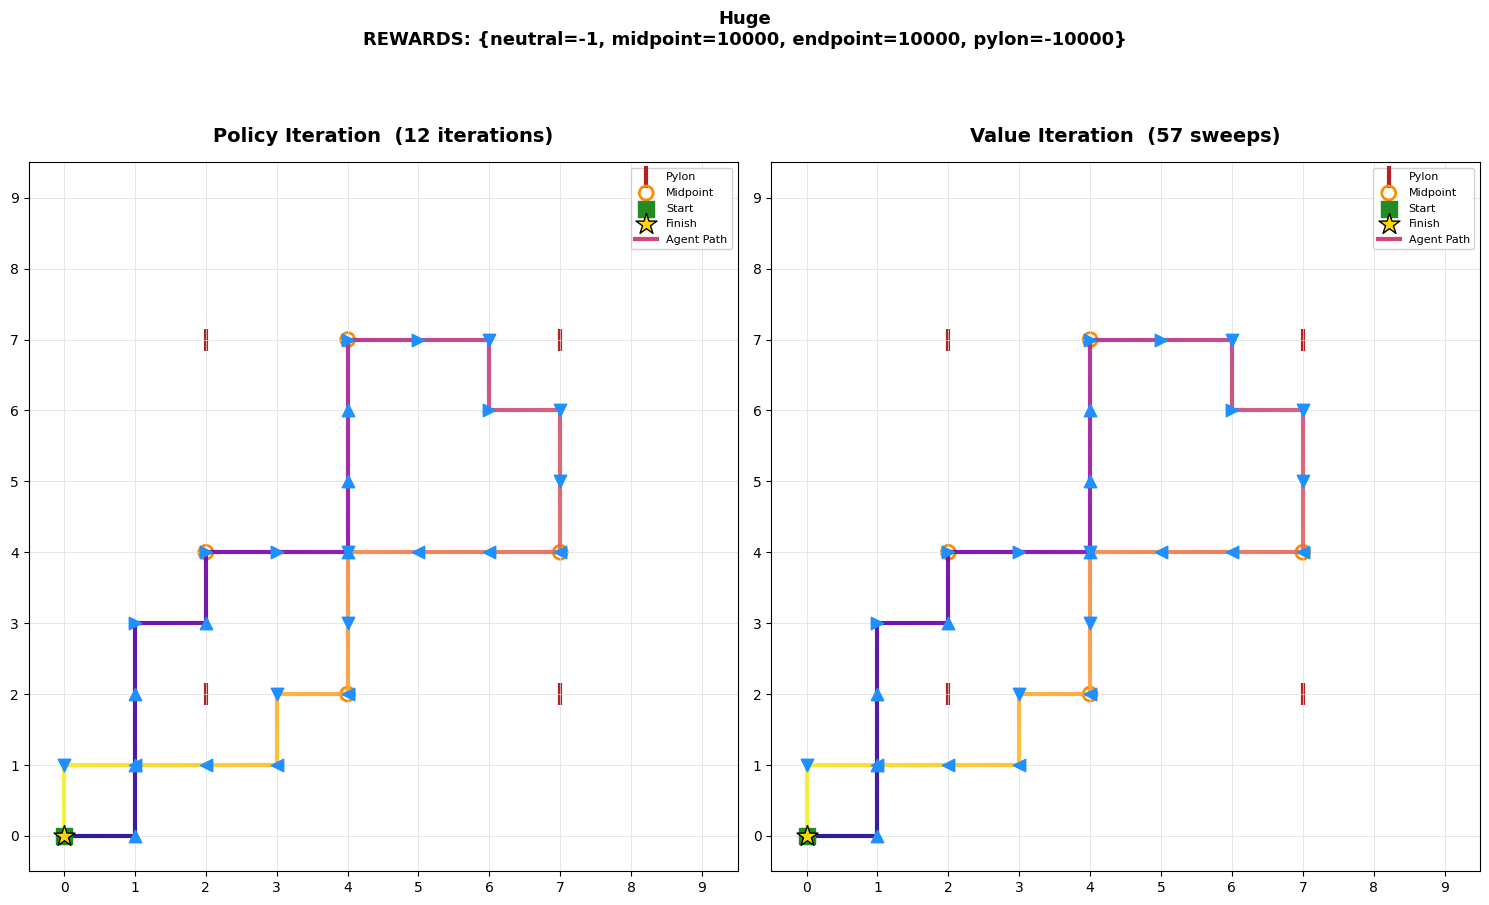

REWARD CONFIG : Huge
REWARDS       : {'neutral': -1, 'midpoint': 10000, 'endpoint': 10000, 'pylon': -10000}
                              Policy Iteration     Value Iteration
  Outer loop count                          12                  57
  Time (ms)                            1242.54             1202.18



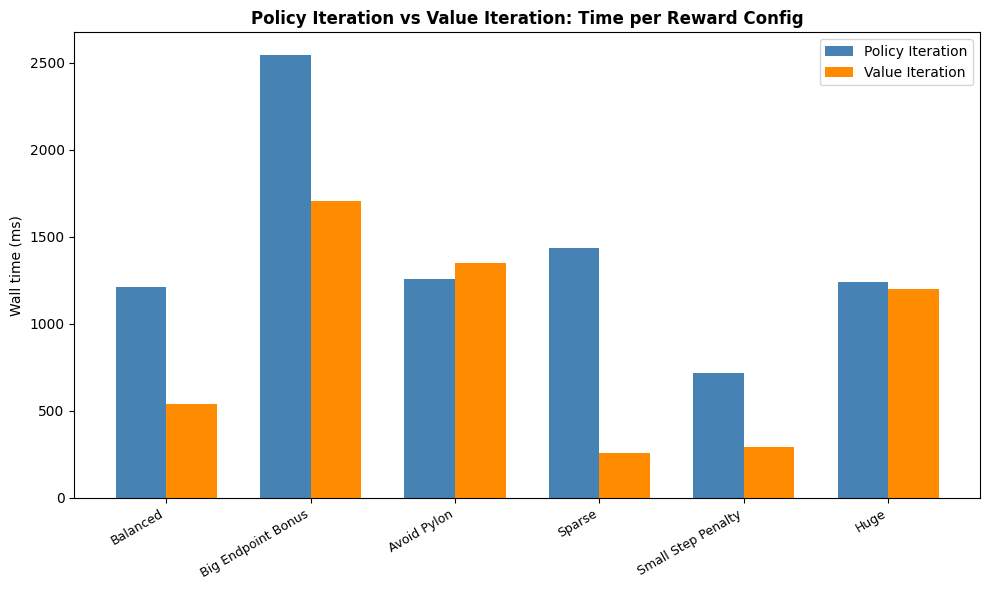

In [11]:
# Reward analysis by outer loop and time

import time

REWARD_CONFIGS = {
    "Balanced":                         {"neutral": -1,   "midpoint": 10, "endpoint": 10,   "pylon": -10},
    "Big Endpoint Bonus":               {"neutral": -1,   "midpoint": 10, "endpoint": 1000, "pylon": -10},
    "Avoid Pylon":                      {"neutral": -1,   "midpoint": 1,  "endpoint": 10,   "pylon": -100},
    "Sparse":                           {"neutral": 0,    "midpoint": 0,  "endpoint": 1,    "pylon": -1},
    "Small Step Penalty":               {"neutral": -0.1, "midpoint": 1,  "endpoint": 1,    "pylon": -1},
    "Huge":                             {"neutral": -1, "midpoint": 10000,  "endpoint": 10000,    "pylon": -10000},

}

def compare_pi_vi(config_name, rewards, grid_n=10, discount_factor=0.9, theta=0.1):
    # Run Policy Iteration
    PI_env = SimplePURT(GRID_N=grid_n, REWARDS=rewards)
    t0 = time.perf_counter()
    PI_policy, PI_V, PI_n_iter = policy_iteration(PI_env, discount_factor=discount_factor, theta=theta)
    PI_time = time.perf_counter() - t0

    # Run Value Iteration
    VI_env = SimplePURT(GRID_N=grid_n, REWARDS=rewards)
    t0 = time.perf_counter()
    VI_policy, VI_V, VI_n_iter = value_iteration(VI_env, discount_factor=discount_factor, theta=theta)
    VI_time = time.perf_counter() - t0

    # Render both resulting policies side-by-side in one figure
    fig, axes = plt.subplots(1, 2, figsize=(15, 10))
    test_policy(PI_env, PI_policy, ax=axes[0], title=f"Policy Iteration  ({PI_n_iter} iterations)", legend_outside=False)
    test_policy(VI_env, VI_policy, ax=axes[1], title=f"Value Iteration  ({VI_n_iter} sweeps)", legend_outside=False)

    reward_str = ", ".join(f"{k}={v}" for k, v in rewards.items())
    fig.suptitle(f"{config_name}\nREWARDS: {{{reward_str}}}", fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.show()

    print("=" * 78)
    print(f"REWARD CONFIG : {config_name}")
    print(f"REWARDS       : {rewards}")
    print(f"  {'':24}{'Policy Iteration':>20}{'Value Iteration':>20}")
    print(f"  {'Outer loop count':24}{PI_n_iter:>20}{VI_n_iter:>20}")
    print(f"  {'Time (ms)':24}{PI_time*1000:>20.2f}{VI_time*1000:>20.2f}")
    print("=" * 78 + "\n")
    
    return {
        "rewards": rewards,
        "PI_policy": PI_policy, "PI_V": PI_V, "PI_n_iter": PI_n_iter, "PI_time": PI_time,
        "VI_policy": VI_policy, "VI_V": VI_V, "VI_n_iter": VI_n_iter, "VI_time": VI_time,
    }

results = {}
for name, rewards in REWARD_CONFIGS.items():
    results[name] = compare_pi_vi(name, rewards)

# --- New comparison graph: how long PI vs VI take, for every reward config, in one chart ---
config_names = list(results.keys())
pi_time_ms = [results[c]["PI_time"] * 1000 for c in config_names]
vi_time_ms = [results[c]["VI_time"] * 1000 for c in config_names]

x = np.arange(len(config_names))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, pi_time_ms, width, label='Policy Iteration', color='steelblue')
ax.bar(x + width/2, vi_time_ms, width, label='Value Iteration', color='darkorange')
ax.set_ylabel('Wall time (ms)')
ax.set_title('Policy Iteration vs Value Iteration: Time per Reward Config', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(config_names, rotation=30, ha='right', fontsize=9)
ax.legend()
plt.tight_layout()
plt.show()

# --- Animation: agent rollout with live cumulative reward, PI vs VI side-by-side ---
from matplotlib.animation import FuncAnimation
from IPython.display import HTML, display

def rollout_with_rewards(env, policy):
    """Runs the greedy policy once and records the reward received at every step.
    (env.state_history / env.action_history are already tracked by the env itself.)"""
    env.reset()
    rewards = [0.0]  # aligns with state_history[0]: no reward has been earned yet at the start
    while True:
        observation, reward, done, truncated, info = env.step(policy[env.state[0], env.state[1]])
        rewards.append(reward)
        if done or truncated:
            break
    return rewards


def animate_pi_vi_rollout(config_name, rewards_config, PI_policy, VI_policy, grid_n=10, interval=200):
    """Builds one synchronized animation of the PI and VI greedy rollouts side-by-side:
    the agent moving through the grid on top, and its cumulative reward over steps below.
    Reuses already-solved policies rather than re-running planning."""
    PI_env = SimplePURT(GRID_N=grid_n, REWARDS=rewards_config)
    PI_rewards = np.cumsum(rollout_with_rewards(PI_env, PI_policy))
    PI_path_x = np.array([s[0] % grid_n for s in PI_env.state_history])
    PI_path_y = np.array([s[0] // grid_n for s in PI_env.state_history])

    VI_env = SimplePURT(GRID_N=grid_n, REWARDS=rewards_config)
    VI_rewards = np.cumsum(rollout_with_rewards(VI_env, VI_policy))
    VI_path_x = np.array([s[0] % grid_n for s in VI_env.state_history])
    VI_path_y = np.array([s[0] // grid_n for s in VI_env.state_history])

    n_frames = max(len(PI_path_x), len(VI_path_x))

    fig, axes = plt.subplots(2, 2, figsize=(14, 9), gridspec_kw={'height_ratios': [3, 1]})
    ax_grid_pi, ax_grid_vi = axes[0]
    ax_rew_pi, ax_rew_vi = axes[1]

    def setup_grid_ax(ax, env, sub_title):
        ax.set_xlim(-0.5, grid_n - 0.5)
        ax.set_ylim(-0.5, grid_n - 0.5)
        ax.set_xticks(np.arange(grid_n))
        ax.set_yticks(np.arange(grid_n))
        ax.grid(True, color='gainsboro', linewidth=0.5)
        ax.set_aspect('equal')
        px, py = env.PYLON_GRID_COORDINATES[:, 0], env.PYLON_GRID_COORDINATES[:, 1]
        ax.scatter(px, py, color='firebrick', marker='|', s=200, linewidths=3, label='Pylon')
        mx, my = env.PYLON_MIDPOINT_GRID_COORDINATES[:, 0], env.PYLON_MIDPOINT_GRID_COORDINATES[:, 1]
        ax.scatter(mx, my, color='darkorange', marker='o', s=80, facecolors='none', edgecolors='darkorange', linewidths=2, label='Midpoint')
        ax.set_title(sub_title, fontweight='bold')
        ax.legend(loc='upper right', fontsize=7)

    setup_grid_ax(ax_grid_pi, PI_env, "Policy Iteration")
    setup_grid_ax(ax_grid_vi, VI_env, "Value Iteration")

    pi_line, = ax_grid_pi.plot([], [], color='dodgerblue', linewidth=2.5, zorder=2)
    pi_agent = ax_grid_pi.scatter([], [], color='forestgreen', s=140, zorder=3, edgecolor='black')
    vi_line, = ax_grid_vi.plot([], [], color='dodgerblue', linewidth=2.5, zorder=2)
    vi_agent = ax_grid_vi.scatter([], [], color='forestgreen', s=140, zorder=3, edgecolor='black')

    for ax, cum_reward in [(ax_rew_pi, PI_rewards), (ax_rew_vi, VI_rewards)]:
        ax.set_xlim(0, n_frames)
        ax.set_ylim(min(0, cum_reward.min()) - 1, max(0, cum_reward.max()) + 1)
        ax.axhline(0, color='gray', linewidth=0.7)
        ax.set_xlabel('Step')
        ax.set_ylabel('Cumulative Reward')

    pi_reward_line, = ax_rew_pi.plot([], [], color='steelblue', linewidth=2)
    vi_reward_line, = ax_rew_vi.plot([], [], color='darkorange', linewidth=2)

    reward_str = ", ".join(f"{k}={v}" for k, v in rewards_config.items())
    fig.suptitle(f"{config_name} — Rollout Animation\nREWARDS: {{{reward_str}}}", fontsize=13, fontweight='bold')

    def update(frame):
        pi_i = min(frame, len(PI_path_x) - 1)
        vi_i = min(frame, len(VI_path_x) - 1)

        pi_line.set_data(PI_path_x[:pi_i + 1], PI_path_y[:pi_i + 1])
        pi_agent.set_offsets([[PI_path_x[pi_i], PI_path_y[pi_i]]])
        pi_reward_line.set_data(np.arange(pi_i + 1), PI_rewards[:pi_i + 1])
        ax_rew_pi.set_title(f"PI cumulative reward: {PI_rewards[pi_i]:.1f}", fontsize=9)

        vi_line.set_data(VI_path_x[:vi_i + 1], VI_path_y[:vi_i + 1])
        vi_agent.set_offsets([[VI_path_x[vi_i], VI_path_y[vi_i]]])
        vi_reward_line.set_data(np.arange(vi_i + 1), VI_rewards[:vi_i + 1])
        ax_rew_vi.set_title(f"VI cumulative reward: {VI_rewards[vi_i]:.1f}", fontsize=9)

        return pi_line, pi_agent, pi_reward_line, vi_line, vi_agent, vi_reward_line

    anim = FuncAnimation(fig, update, frames=n_frames, interval=interval, blit=False, repeat=False)
    plt.close(fig)
    return anim

animation_config_name = "Balanced"
rollout_anim = animate_pi_vi_rollout(
    animation_config_name,
    REWARD_CONFIGS[animation_config_name],
    results[animation_config_name]["PI_policy"],
    results[animation_config_name]["VI_policy"],
)
display(HTML(rollout_anim.to_jshtml()))

100%|██████████| 10/10 [00:54<00:00,  5.47s/it]


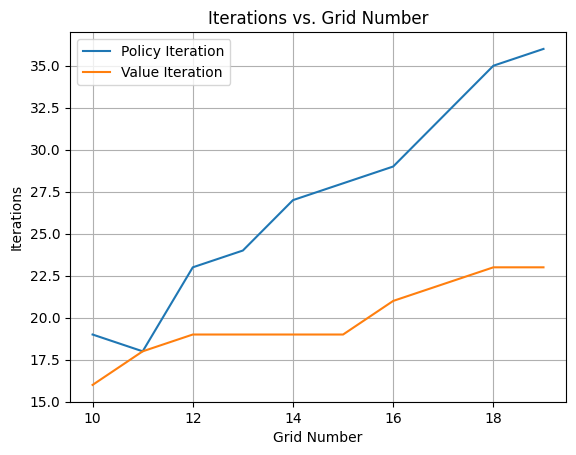

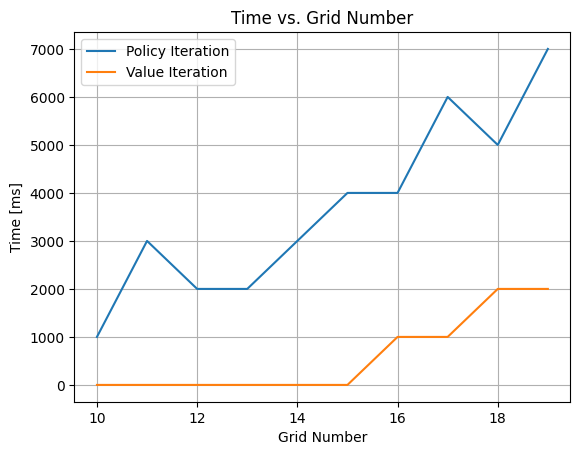

In [12]:
from tqdm import tqdm

# Grid Size

grid_range = range(10,20,1)
PI_n = np.zeros_like(grid_range)
VI_n = np.zeros_like(grid_range)
PI_t = np.zeros_like(grid_range)
VI_t = np.zeros_like(grid_range)

for i in tqdm(range(len(grid_range))):
    env = SimplePURT(GRID_N=grid_range[i])
    env.reset()
    pt0 = time.perf_counter()
    PI_policy, PI_V, PI_n_iter = policy_iteration(env, discount_factor=0.9, theta=0.1)
    pt1 = time.perf_counter()
    env.reset()
    vt0 = time.perf_counter()
    VI_policy, VI_V, VI_n_iter = value_iteration(env, discount_factor=0.9, theta=0.1)
    vt1 = time.perf_counter()
    PI_n[i] = PI_n_iter
    VI_n[i] = VI_n_iter
    PI_t[i] = pt1 - pt0
    VI_t[i] = vt1 - vt0
    
# Iterations vs. Grid Number
plt.plot(grid_range, PI_n, grid_range, VI_n)
plt.legend(["Policy Iteration", "Value Iteration"])
plt.xlabel("Grid Number")
plt.ylabel("Iterations")
plt.grid(True)
plt.title("Iterations vs. Grid Number")
plt.show()

# Time vs. Grid Number
plt.plot(grid_range, PI_t*1000, grid_range, VI_t*1000)
plt.legend(["Policy Iteration", "Value Iteration"])
plt.xlabel("Grid Number")
plt.ylabel("Time [ms]")
plt.grid(True)
plt.title("Time vs. Grid Number")
plt.show()
    

## Noisy Environment

In [13]:
VI_policy, VI_V, VI_n_iter = value_iteration(SimplePURT(NOISE=0.25), discount_factor=0.9, theta=0.1)

### Noise Resilient Policy in Noisy Environment

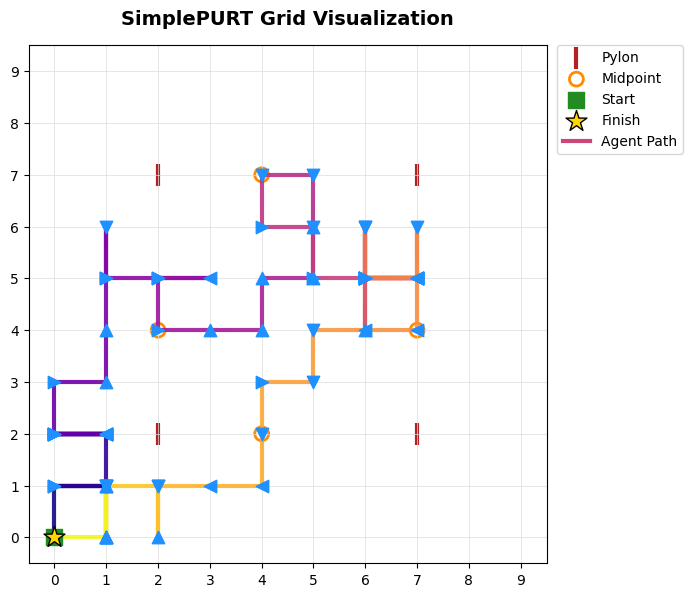

In [32]:
test_policy(SimplePURT(NOISE=0.25),VI_policy)

### Noise Resilient Policy in Noiseless Environment

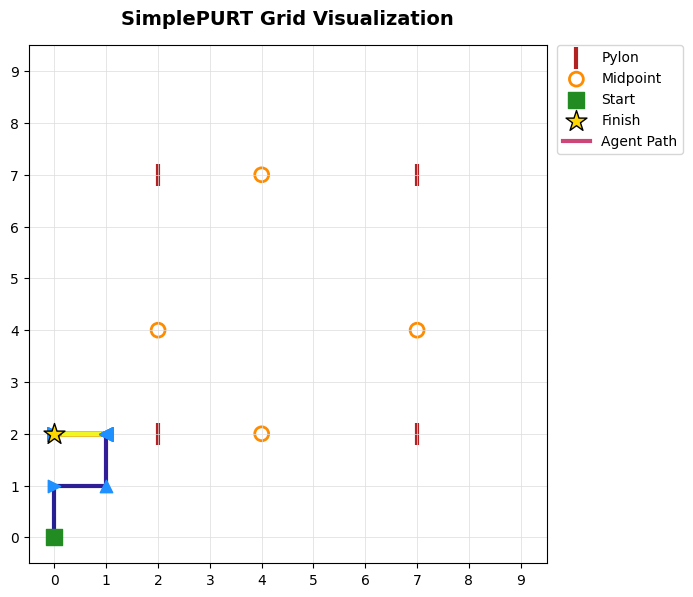

In [34]:

test_policy(SimplePURT(NOISE=0),VI_policy)

100%|██████████| 10/10 [00:39<00:00,  3.93s/it]


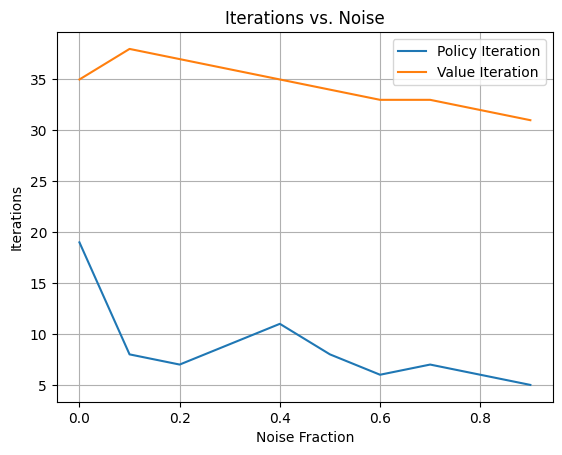

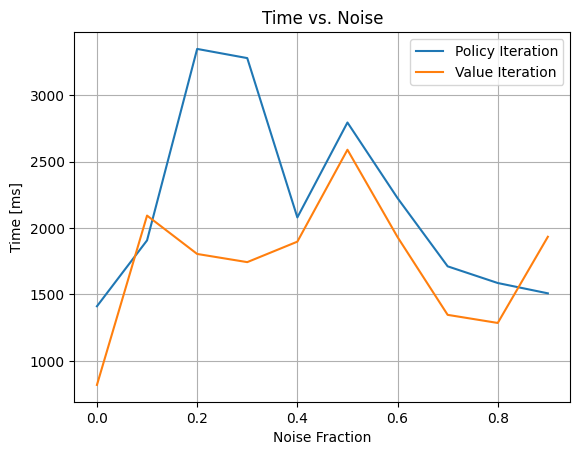

In [16]:
# Noise

noise_range = np.arange(0,1,0.1)
PI_n = np.zeros_like(noise_range)
VI_n = np.zeros_like(noise_range)
PI_t = np.zeros_like(noise_range)
VI_t = np.zeros_like(noise_range)

for i in tqdm(range(len(noise_range))):
    env = SimplePURT(NOISE=noise_range[i])
    env.reset()
    pt0 = time.perf_counter()
    PI_policy, PI_V, PI_n_iter = policy_iteration(env, discount_factor=0.9, theta=0.001)
    pt1 = time.perf_counter()
    env.reset()
    vt0 = time.perf_counter()
    VI_policy, VI_V, VI_n_iter = value_iteration(env, discount_factor=0.9, theta=0.001)
    vt1 = time.perf_counter()
    PI_n[i] = PI_n_iter
    VI_n[i] = VI_n_iter
    PI_t[i] = pt1 - pt0
    VI_t[i] = vt1 - vt0
    
# Iterations vs. Noise
plt.plot(noise_range, PI_n, noise_range, VI_n)
plt.legend(["Policy Iteration", "Value Iteration"])
plt.xlabel("Noise Fraction")
plt.ylabel("Iterations")
plt.grid(True)
plt.title("Iterations vs. Noise")
plt.show()

# Time vs. Noise
plt.plot(noise_range, PI_t*1000, noise_range, VI_t*1000)
plt.legend(["Policy Iteration", "Value Iteration"])
plt.xlabel("Noise Fraction")
plt.ylabel("Time [ms]")
plt.grid(True)
plt.title("Time vs. Noise")
plt.show()